#### 라이브러리 생성

In [6]:
import pandas as pd
import numpy as np
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt
import seaborn as sns
import platform

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.2f}".format)

# 한글 폰트 설정
if platform.system() == "Darwin":      # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":   # Windows
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                                  # Linux / Colab
    plt.rcParams["font.family"] = "NanumGothic"

# 마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

# 그래프 기본 크기
sns.set_context("notebook")

#### 파일 불러오기

In [7]:
files = [
    "2019-Oct.csv",
    "2019-Nov.csv"
]

chunksize = 500000

#### 1.1 플래그 변수 추가

In [8]:
# 필요한 컬럼만 불러오기
usecols = [
    "event_time", "event_type", "product_id", "category_code",
    "brand", "price", "user_id", "user_session"
]

def add_missing_flags(chunk):
    df = chunk.copy()

    # 문자열 공백 제거 + 빈 문자열 결측 처리
    for col in ["event_type", "category_code", "brand", "user_session"]:
        if col in df.columns:
            df[col] = df[col].astype("string").str.strip()
            df[col] = df[col].replace("", pd.NA)

    # 1. 결측 플래그 생성
    df["brand_missing"] = df["brand"].isna().astype("int")
    df["category_missing"] = df["category_code"].isna().astype("int")

    # price가 결측, 0 이하일때 변수 invalid 생성
    df["price_invalid"] = ((df["price"].isna()) | (df["price"] <= 0)).astype("int")

    # 2. 결측 대체 컬럼 생성
    df["brand_filled"] = df["brand"].fillna("unknown_brand")
    df["category_filled"] = df["category_code"].fillna("unknown_category")

    # 3. 스마트폰 여부 파생
    df["is_smartphone"] = (
        df["category_filled"]
        .str.contains(r"smartphone", case=False, na=False)
        .astype("int")
    )

    return df

summary_list = []

for file in files:
    file_name = Path(file).name

    total_rows = 0
    brand_missing_cnt = 0
    category_missing_cnt = 0
    price_invalid_cnt = 0
    smartphone_rows = 0

    reader = pd.read_csv(
        file,
        usecols=usecols,
        chunksize=chunksize
    )

    for chunk in reader:
        df = add_missing_flags(chunk)

        total_rows += len(df)
        brand_missing_cnt += df["brand_missing"].sum()
        category_missing_cnt += df["category_missing"].sum()
        price_invalid_cnt += df["price_invalid"].sum()
        smartphone_rows += df["is_smartphone"].sum()

    summary_list.append({
        "file": file_name,
        "total_rows": total_rows,
        "brand 결측 수": int(brand_missing_cnt),
        "brand 결측 비율": round(brand_missing_cnt / total_rows * 100, 2),
        "category 결측 수": int(category_missing_cnt),
        "category 결측 비율": round(category_missing_cnt / total_rows * 100, 2),
        "price 0 수": int(price_invalid_cnt),
        "price 0 비율": round(price_invalid_cnt / total_rows * 100, 2),
        "smartphone_rows": int(smartphone_rows),
        "smartphone 비율": round(smartphone_rows / total_rows * 100, 2)
    })

summary_df = pd.DataFrame(summary_list)
display(summary_df)

,file,total_rows,brand 결측 수,brand 결측 비율,category 결측 수,category 결측 비율,price 0 수,price 0 비율,smartphone_rows,smartphone 비율
0,2019-Oct.csv,42448764,6117080,14.41,13515609,31.84,68673,0.16,11507231,27.11
1,2019-Nov.csv,67501979,9224078,13.66,21898171,32.44,188088,0.28,16375000,24.26


해석
- brand와 category_code결측 비율이 의미 있는 비중
  - category_code 결측은 3/1 정도로 있어 삭제 X
- price가 0인 비율은 적지만, 비정상 데이터일 가능성이 높아 따로 확인

결과
- brand, category_code는 결측 여부를 플래그로 보존 (brand_missing, category_missing)
- 결측을 'unknown_brand', 'category_brand'로 대체한 컬럼 추가 생성(brand_filled, category_filled)
- price = 0인 칼럼 'price_invalid' 플래그 생성해 비교

<br>
=> 결측과 이상치를 제거하지 않고, 원본 + 결측 채운 칼럼 + 플래그 칼럼을 같이 유지한 방향으로 진행

#### 1.2 smartphone 통계

In [9]:
smartphone_summary_list = []

for file in files:
    file_name = Path(file).name

    smartphone_total = 0
    brand_missing_cnt = 0
    category_missing_cnt = 0
    price_invalid_cnt = 0

    reader = pd.read_csv(
        file,
        usecols=usecols,
        chunksize=chunksize
    )

    for chunk in reader:
        df = add_missing_flags(chunk)
        phone_df = df[df["is_smartphone"] == 1]

        smartphone_total += len(phone_df)
        brand_missing_cnt += phone_df["brand_missing"].sum()
        category_missing_cnt += phone_df["category_missing"].sum()
        price_invalid_cnt += phone_df["price_invalid"].sum()

    smartphone_summary_list.append({
        "file": file_name,
        "smartphone_total_rows": int(smartphone_total),
        "brand 결측 수": int(brand_missing_cnt),
        "brand 결측 비율": round((brand_missing_cnt / smartphone_total * 100), 2) if smartphone_total > 0 else 0,
        "price_invalid 수": int(price_invalid_cnt),
        "price_invalid 비율": round((price_invalid_cnt / smartphone_total * 100), 2) if smartphone_total > 0 else 0
    })

smartphone_summary_df = pd.DataFrame(smartphone_summary_list)
display(smartphone_summary_df)

,file,smartphone_total_rows,brand 결측 수,brand 결측 비율,price_invalid 수,price_invalid 비율
0,2019-Oct.csv,11507231,21910,0.19,4804,0.04
1,2019-Nov.csv,16375000,21418,0.13,6506,0.04


해석
- 스마트폰은 brand 결측이 매우 낮음 (0.2%이하)
- 가격이 0인 비율도 매우 낮음 (0.05%이하)
- 스마트폰은 전체 데이터에 비에 안정적(크게 결측치들에 대해 영향을 받지x)

결과
- 왜곡이 적지만, 스마트폰도 분석에서 플래그는 유지(틀 유지)
- 추가로 구매 행동 분석 진행

=> 전체에 비에 스마트폰은 안정적이지만, 결측 여부에 따른 전환 확인 후 진행

#### 2.1 session-item 기준 집계 테이블

In [10]:
def make_session_item_chunk(df):
    temp = df.copy()

    # 이벤트 더미화
    temp["view_yn"] = (temp["event_type"] == "view").astype("int")
    temp["cart_yn"] = (temp["event_type"] == "cart").astype("int")
    temp["purchase_yn"] = (temp["event_type"] == "purchase").astype("int")

    # session-item 기준 집계
    grouped = temp.groupby(["user_session", "product_id"], as_index=False).agg(
        view_yn=("view_yn", "max"),
        cart_yn=("cart_yn", "max"),
        purchase_yn=("purchase_yn", "max"),

        brand_missing=("brand_missing", "max"),
        category_missing=("category_missing", "max"),
        price_invalid=("price_invalid", "max"),

        is_smartphone=("is_smartphone", "max")
    )

    return grouped


def update_summary(summary_dict, df, group_col, file_name):
    for group_value, sub in df.groupby(group_col):
        key = (file_name, group_col, int(group_value))

        summary_dict[key]["session_item_count"] += len(sub)
        summary_dict[key]["view_count"] += int(sub["view_yn"].sum())
        summary_dict[key]["cart_count"] += int(sub["cart_yn"].sum())
        summary_dict[key]["purchase_count"] += int(sub["purchase_yn"].sum())


# 누적 요약 저장용
summary_dict = defaultdict(lambda: {
    "session_item_count": 0,
    "view_count": 0,
    "cart_count": 0,
    "purchase_count": 0
})

# 파일별 전체 session-item 수만 따로 확인
overall_summary = []

for file in files:
    file_name = Path(file).name
    print(f"\n===== {file_name} 처리 중 =====")

    total_session_items = 0
    total_smartphone_session_items = 0

    reader = pd.read_csv(
        file,
        usecols=usecols,
        chunksize=chunksize
    )

    for i, chunk in enumerate(reader, start=1):
        df = add_missing_flags(chunk)
        session_item_chunk = make_session_item_chunk(df)

        total_session_items += len(session_item_chunk)
        total_smartphone_session_items += int(session_item_chunk["is_smartphone"].sum())

        # 전체 기준 비교
        update_summary(summary_dict, session_item_chunk, "brand_missing", file_name)
        update_summary(summary_dict, session_item_chunk, "category_missing", file_name)
        update_summary(summary_dict, session_item_chunk, "price_invalid", file_name)

        if i % 10 == 0:
            print(f"  - chunk {i}개 처리 완료")

    overall_summary.append({
        "file": file_name,
        "session_item_count": total_session_items,
        "smartphone_session_item_count": total_smartphone_session_items,
        "smartphone_pct": round(total_smartphone_session_items / total_session_items * 100, 2)
        if total_session_items > 0 else 0
    })

overall_summary_df = pd.DataFrame(overall_summary)
display(overall_summary_df)


===== 2019-Oct.csv 처리 중 =====
  - chunk 10개 처리 완료
  - chunk 20개 처리 완료
  - chunk 30개 처리 완료
  - chunk 40개 처리 완료
  - chunk 50개 처리 완료
  - chunk 60개 처리 완료
  - chunk 70개 처리 완료
  - chunk 80개 처리 완료

===== 2019-Nov.csv 처리 중 =====
  - chunk 10개 처리 완료
  - chunk 20개 처리 완료
  - chunk 30개 처리 완료
  - chunk 40개 처리 완료
  - chunk 50개 처리 완료
  - chunk 60개 처리 완료
  - chunk 70개 처리 완료
  - chunk 80개 처리 완료
  - chunk 90개 처리 완료
  - chunk 100개 처리 완료
  - chunk 110개 처리 완료
  - chunk 120개 처리 완료
  - chunk 130개 처리 완료


,file,session_item_count,smartphone_session_item_count,smartphone_pct
0,2019-Oct.csv,27917253,7102649,25.44
1,2019-Nov.csv,42378839,9675448,22.83


해석
- user_session + product_id 기준으로 진행
  - session_item_count로 session_item 테이블 생성
- session_item 기준으로 진행함으로써, 한 세션 특정 상품에 대해 조회, 장바구니, 구매가 발생했는지 파악
  - row로 진행시, 같은 상품에 대한 이벤트가 반복되어서 비교시 영향이 있음

결과
- 결측 이상치는 row 기준이 아닌 session-item 기준으로 진행
- 이벤트 전환율 비교 또한 session-item로 진행 

=> 결측 이상치 영향 비교를 row가 아닌 session-item로

In [11]:
summary_rows = []

for (file_name, group_col, group_value), vals in summary_dict.items():
    session_cnt = vals["session_item_count"]
    view_cnt = vals["view_count"]
    cart_cnt = vals["cart_count"]
    purchase_cnt = vals["purchase_count"]

    summary_rows.append({
        "file": file_name,
        "group_col": group_col,
        "group_value": group_value,
        "session_item_count": session_cnt,
        "view_count": view_cnt,
        "cart_count": cart_cnt,
        "purchase_count": purchase_cnt,
        "view_rate": round(view_cnt / session_cnt * 100, 2) if session_cnt > 0 else 0,
        "cart_rate": round(cart_cnt / session_cnt * 100, 2) if session_cnt > 0 else 0,
        "purchase_rate": round(purchase_cnt / session_cnt * 100, 2) if session_cnt > 0 else 0,
        "cart_to_purchase_rate": round(purchase_cnt / cart_cnt * 100, 2) if cart_cnt > 0 else 0
    })

session_item_summary_df = pd.DataFrame(summary_rows).sort_values(
    ["file", "group_col", "group_value"]
).reset_index(drop=True)

display(session_item_summary_df)

,file,group_col,group_value,session_item_count,view_count,cart_count,purchase_count,view_rate,cart_rate,purchase_rate,cart_to_purchase_rate
0,2019-Nov.csv,brand_missing,0,36007109,35980051,1882395,789134,99.92,5.23,2.19,41.92
1,2019-Nov.csv,brand_missing,1,6371730,6369754,186488,70242,99.97,2.93,1.10,37.67
2,2019-Nov.csv,category_missing,0,27886163,27863246,1481396,636673,99.92,5.31,2.28,42.98
3,2019-Nov.csv,category_missing,1,14492676,14486559,587487,222703,99.96,4.05,1.54,37.91
4,2019-Nov.csv,price_invalid,0,42244269,42215249,2065456,858623,99.93,4.89,2.03,41.57
5,2019-Nov.csv,price_invalid,1,134570,134556,3427,753,99.99,2.55,0.56,21.97
6,2019-Oct.csv,brand_missing,0,23493234,23488618,616757,635425,99.98,2.63,2.70,103.03
7,2019-Oct.csv,brand_missing,1,4424019,4423773,12819,55465,99.99,0.29,1.25,432.68
8,2019-Oct.csv,category_missing,0,18465190,18461305,555512,526640,99.98,3.01,2.85,94.80
9,2019-Oct.csv,category_missing,1,9452063,9451086,74064,164250,99.99,0.78,1.74,221.77


#### 2.2 스마트폰만

In [12]:
smartphone_summary_dict = defaultdict(lambda: {
    "session_item_count": 0,
    "view_count": 0,
    "cart_count": 0,
    "purchase_count": 0
})

for file in files:
    file_name = Path(file).name
    print(f"\n===== {file_name} 스마트폰 subset 처리 중 =====")

    reader = pd.read_csv(
        file,
        usecols=usecols,
        chunksize=chunksize
    )

    for i, chunk in enumerate(reader, start=1):
        df = add_missing_flags(chunk)
        session_item_chunk = make_session_item_chunk(df)

        phone_df = session_item_chunk[session_item_chunk["is_smartphone"] == 1]

        update_summary(smartphone_summary_dict, phone_df, "brand_missing", file_name)
        update_summary(smartphone_summary_dict, phone_df, "price_invalid", file_name)

        if i % 10 == 0:
            print(f"  - chunk {i}개 처리 완료")


===== 2019-Oct.csv 스마트폰 subset 처리 중 =====
  - chunk 10개 처리 완료
  - chunk 20개 처리 완료
  - chunk 30개 처리 완료
  - chunk 40개 처리 완료
  - chunk 50개 처리 완료
  - chunk 60개 처리 완료
  - chunk 70개 처리 완료
  - chunk 80개 처리 완료

===== 2019-Nov.csv 스마트폰 subset 처리 중 =====
  - chunk 10개 처리 완료
  - chunk 20개 처리 완료
  - chunk 30개 처리 완료
  - chunk 40개 처리 완료
  - chunk 50개 처리 완료
  - chunk 60개 처리 완료
  - chunk 70개 처리 완료
  - chunk 80개 처리 완료
  - chunk 90개 처리 완료
  - chunk 100개 처리 완료
  - chunk 110개 처리 완료
  - chunk 120개 처리 완료
  - chunk 130개 처리 완료


In [13]:
smartphone_rows = []

for (file_name, group_col, group_value), vals in smartphone_summary_dict.items():
    session_cnt = vals["session_item_count"]
    view_cnt = vals["view_count"]
    cart_cnt = vals["cart_count"]
    purchase_cnt = vals["purchase_count"]

    smartphone_rows.append({
        "file": file_name,
        "group_col": group_col,
        "group_value": group_value,
        "session_item_count": session_cnt,
        "view_count": view_cnt,
        "cart_count": cart_cnt,
        "purchase_count": purchase_cnt,
        "view_rate": round(view_cnt / session_cnt * 100, 2) if session_cnt > 0 else 0,
        "cart_rate": round(cart_cnt / session_cnt * 100, 2) if session_cnt > 0 else 0,
        "purchase_rate": round(purchase_cnt / session_cnt * 100, 2) if session_cnt > 0 else 0,
        "cart_to_purchase_rate": round(purchase_cnt / cart_cnt * 100, 2) if cart_cnt > 0 else 0
    })

smartphone_session_item_summary_df = pd.DataFrame(smartphone_rows).sort_values(
    ["file", "group_col", "group_value"]
).reset_index(drop=True)

display(smartphone_session_item_summary_df)

,file,group_col,group_value,session_item_count,view_count,cart_count,purchase_count,view_rate,cart_rate,purchase_rate,cart_to_purchase_rate
0,2019-Nov.csv,brand_missing,0,9662193,9649448,759473,352348,99.87,7.86,3.65,46.39
1,2019-Nov.csv,brand_missing,1,13255,13249,418,147,99.95,3.15,1.11,35.17
2,2019-Nov.csv,price_invalid,0,9671024,9658273,759821,352474,99.87,7.86,3.64,46.39
3,2019-Nov.csv,price_invalid,1,4424,4424,70,21,100.00,1.58,0.47,30.00
4,2019-Oct.csv,brand_missing,0,7088438,7085940,368262,308836,99.96,5.20,4.36,83.86
5,2019-Oct.csv,brand_missing,1,14211,14211,267,406,100.00,1.88,2.86,152.06
6,2019-Oct.csv,price_invalid,0,7099408,7096910,368518,309203,99.96,5.19,4.36,83.90
7,2019-Oct.csv,price_invalid,1,3241,3241,11,39,100.00,0.34,1.20,354.55


#### 3. 결측/이상치 여부별 전환율 비교

In [14]:
step3_compare_df = (
    session_item_summary_df[
        ["file", "group_col", "group_value", "session_item_count", "cart_rate", "purchase_rate"]
    ]
    .sort_values(["file", "group_col", "group_value"])
    .reset_index(drop=True)
)

display(step3_compare_df)

,file,group_col,group_value,session_item_count,cart_rate,purchase_rate
0,2019-Nov.csv,brand_missing,0,36007109,5.23,2.19
1,2019-Nov.csv,brand_missing,1,6371730,2.93,1.10
2,2019-Nov.csv,category_missing,0,27886163,5.31,2.28
3,2019-Nov.csv,category_missing,1,14492676,4.05,1.54
4,2019-Nov.csv,price_invalid,0,42244269,4.89,2.03
5,2019-Nov.csv,price_invalid,1,134570,2.55,0.56
6,2019-Oct.csv,brand_missing,0,23493234,2.63,2.70
7,2019-Oct.csv,brand_missing,1,4424019,0.29,1.25
8,2019-Oct.csv,category_missing,0,18465190,3.01,2.85
9,2019-Oct.csv,category_missing,1,9452063,0.78,1.74


해석
- 결측/이상치 그룹(1)이 정상 그룹(0)보다 낮게 나옴
- 단순 누락이 아닌 행동 특성과 연관되어 있을 가능성 있음

결과
- 분석 변수 유지

=> 행동 변수 설명하는 걸 유지

In [15]:
# 스마트폰만

step3_phone_compare_df = (
    smartphone_session_item_summary_df[
        ["file", "group_col", "group_value", "session_item_count", "cart_rate", "purchase_rate"]
    ]
    .sort_values(["file", "group_col", "group_value"])
    .reset_index(drop=True)
)

display(step3_phone_compare_df)

,file,group_col,group_value,session_item_count,cart_rate,purchase_rate
0,2019-Nov.csv,brand_missing,0,9662193,7.86,3.65
1,2019-Nov.csv,brand_missing,1,13255,3.15,1.11
2,2019-Nov.csv,price_invalid,0,9671024,7.86,3.64
3,2019-Nov.csv,price_invalid,1,4424,1.58,0.47
4,2019-Oct.csv,brand_missing,0,7088438,5.20,4.36
5,2019-Oct.csv,brand_missing,1,14211,1.88,2.86
6,2019-Oct.csv,price_invalid,0,7099408,5.19,4.36
7,2019-Oct.csv,price_invalid,1,3241,0.34,1.20


In [16]:
# 그룹별 purchase_rate 차이

purchase_compare = (
    session_item_summary_df.pivot_table(
        index=["file", "group_col"],
        columns="group_value",
        values="purchase_rate"
    )
    .reset_index()
)

purchase_compare.columns = ["file", "group_col", "purchase_rate_0", "purchase_rate_1"]
purchase_compare["diff_1_minus_0"] = (
    purchase_compare["purchase_rate_1"] - purchase_compare["purchase_rate_0"]
)

display(purchase_compare)

,file,group_col,purchase_rate_0,purchase_rate_1,diff_1_minus_0
0,2019-Nov.csv,brand_missing,2.19,1.10,-1.09
1,2019-Nov.csv,category_missing,2.28,1.54,-0.74
2,2019-Nov.csv,price_invalid,2.03,0.56,-1.47
3,2019-Oct.csv,brand_missing,2.70,1.25,-1.45
4,2019-Oct.csv,category_missing,2.85,1.74,-1.11
5,2019-Oct.csv,price_invalid,2.48,0.81,-1.67


해석
- 모두 diff_1_minus_0가 마이너스
- 결측/이상치가 있는 그룹(1)의 구매 전환율이 정상(0)보다 낮음

결과
- price_invalid는 행동분석에서는 유지, 매출/AOV 같은 금액 분석에는 제외

In [17]:
# 그룹별 purchase_rate 차이 스마트폰

phone_purchase_compare = (
    smartphone_session_item_summary_df.pivot_table(
        index=["file", "group_col"],
        columns="group_value",
        values="purchase_rate"
    )
    .reset_index()
)

phone_purchase_compare.columns = ["file", "group_col", "purchase_rate_0", "purchase_rate_1"]
phone_purchase_compare["diff_1_minus_0"] = (
    phone_purchase_compare["purchase_rate_1"] - phone_purchase_compare["purchase_rate_0"]
)

display(phone_purchase_compare)

,file,group_col,purchase_rate_0,purchase_rate_1,diff_1_minus_0
0,2019-Nov.csv,brand_missing,3.65,1.11,-2.54
1,2019-Nov.csv,price_invalid,3.64,0.47,-3.17
2,2019-Oct.csv,brand_missing,4.36,2.86,-1.50
3,2019-Oct.csv,price_invalid,4.36,1.20,-3.16


해석
- 전체와 같이 결측/이상치가 정상보다 낮음
  - 스마트폰이 더 뚜렷하게 보임

결과
- 분석 결과 비율이 낮다고 제거하면 X
- 의미가 있어 남겨두어야 함

=> 스마트폰도 결측/이상치 플래그를 유지하는 전처리 진행

#### 4. 교차검증

In [18]:
def update_cross_summary(summary_dict, df, file_name, col1, col2):
    grouped = (
        df.groupby([col1, col2], dropna=False)
          .agg(
              session_item_count=("product_id", "size"),
              cart_count=("cart_yn", "sum"),
              purchase_count=("purchase_yn", "sum")
          )
          .reset_index()
    )

    for _, row in grouped.iterrows():
        key = (file_name, col1, col2, row[col1], row[col2])
        summary_dict[key]["session_item_count"] += int(row["session_item_count"])
        summary_dict[key]["cart_count"] += int(row["cart_count"])
        summary_dict[key]["purchase_count"] += int(row["purchase_count"])

In [19]:
# 교차 검증

cross_pairs = [
    ("brand_missing", "is_smartphone"),
    ("category_missing", "is_smartphone"),
    ("price_invalid", "is_smartphone"),
    ("brand_missing", "category_missing")
]

cross_summary_dict = defaultdict(lambda: {
    "session_item_count": 0,
    "cart_count": 0,
    "purchase_count": 0
})

for file in files:
    file_name = Path(file).name
    print(f"\n===== {file_name} 교차 검증 처리 중 =====")

    reader = pd.read_csv(
        file,
        usecols=usecols,
        chunksize=chunksize
    )

    for i, chunk in enumerate(reader, start=1):
        df = add_missing_flags(chunk)
        session_item_chunk = make_session_item_chunk(df)

        for col1, col2 in cross_pairs:
            update_cross_summary(cross_summary_dict, session_item_chunk, file_name, col1, col2)

        if i % 10 == 0:
            print(f"{file_name}: {i}개 chunk 처리 완료")


===== 2019-Oct.csv 교차 검증 처리 중 =====
2019-Oct.csv: 10개 chunk 처리 완료
2019-Oct.csv: 20개 chunk 처리 완료
2019-Oct.csv: 30개 chunk 처리 완료
2019-Oct.csv: 40개 chunk 처리 완료
2019-Oct.csv: 50개 chunk 처리 완료
2019-Oct.csv: 60개 chunk 처리 완료
2019-Oct.csv: 70개 chunk 처리 완료
2019-Oct.csv: 80개 chunk 처리 완료

===== 2019-Nov.csv 교차 검증 처리 중 =====
2019-Nov.csv: 10개 chunk 처리 완료
2019-Nov.csv: 20개 chunk 처리 완료
2019-Nov.csv: 30개 chunk 처리 완료
2019-Nov.csv: 40개 chunk 처리 완료
2019-Nov.csv: 50개 chunk 처리 완료
2019-Nov.csv: 60개 chunk 처리 완료
2019-Nov.csv: 70개 chunk 처리 완료
2019-Nov.csv: 80개 chunk 처리 완료
2019-Nov.csv: 90개 chunk 처리 완료
2019-Nov.csv: 100개 chunk 처리 완료
2019-Nov.csv: 110개 chunk 처리 완료
2019-Nov.csv: 120개 chunk 처리 완료
2019-Nov.csv: 130개 chunk 처리 완료


In [20]:
# 전체 결과표
cross_rows = []

for (file_name, col1, col2, val1, val2), vals in cross_summary_dict.items():
    session_cnt = vals["session_item_count"]
    cart_cnt = vals["cart_count"]
    purchase_cnt = vals["purchase_count"]

    cross_rows.append({
        "file": file_name,
        "col1": col1,
        "col2": col2,
        "value1": val1,
        "value2": val2,
        "session_item_count": session_cnt,
        "cart_count": cart_cnt,
        "purchase_count": purchase_cnt,
        "cart_rate": round(cart_cnt / session_cnt * 100, 2) if session_cnt > 0 else 0,
        "purchase_rate": round(purchase_cnt / session_cnt * 100, 2) if session_cnt > 0 else 0
    })

cross_summary_df = pd.DataFrame(cross_rows).sort_values(
    ["file", "col1", "col2", "value1", "value2"]
).reset_index(drop=True)

display(cross_summary_df)

,file,col1,col2,value1,value2,session_item_count,cart_count,purchase_count,cart_rate,purchase_rate
0,2019-Nov.csv,brand_missing,category_missing,0,0,25489947,1419485,614190,5.57,2.41
1,2019-Nov.csv,brand_missing,category_missing,0,1,10517162,462910,174944,4.40,1.66
2,2019-Nov.csv,brand_missing,category_missing,1,0,2396216,61911,22483,2.58,0.94
3,2019-Nov.csv,brand_missing,category_missing,1,1,3975514,124577,47759,3.13,1.20
4,2019-Nov.csv,brand_missing,is_smartphone,0,0,26344916,1122922,436786,4.26,1.66
5,2019-Nov.csv,brand_missing,is_smartphone,0,1,9662193,759473,352348,7.86,3.65
6,2019-Nov.csv,brand_missing,is_smartphone,1,0,6358475,186070,70095,2.93,1.10
7,2019-Nov.csv,brand_missing,is_smartphone,1,1,13255,418,147,3.15,1.11
8,2019-Nov.csv,category_missing,is_smartphone,0,0,18210715,721505,284178,3.96,1.56
9,2019-Nov.csv,category_missing,is_smartphone,0,1,9675448,759891,352495,7.85,3.64


해석
- 결측/이상치가 특정 부분에 몰려있는지, 다른 결측과 같이 나타는지 교차 검증
  - 특정 편중 문제인지, 구조적 문제인지 확인

In [21]:
# brand_missing × is_smartphone
display(
    cross_summary_df[
        (cross_summary_df["col1"] == "brand_missing") &
        (cross_summary_df["col2"] == "is_smartphone")
    ]
)

# category_missing × is_smartphone
display(
    cross_summary_df[
        (cross_summary_df["col1"] == "category_missing") &
        (cross_summary_df["col2"] == "is_smartphone")
    ]
)

# price_invalid × is_smartphone
display(
    cross_summary_df[
        (cross_summary_df["col1"] == "price_invalid") &
        (cross_summary_df["col2"] == "is_smartphone")
    ]
)

# brand_missing × category_missing
display(
    cross_summary_df[
        (cross_summary_df["col1"] == "brand_missing") &
        (cross_summary_df["col2"] == "category_missing")
    ]
)

,file,col1,col2,value1,value2,session_item_count,cart_count,purchase_count,cart_rate,purchase_rate
4,2019-Nov.csv,brand_missing,is_smartphone,0,0,26344916,1122922,436786,4.26,1.66
5,2019-Nov.csv,brand_missing,is_smartphone,0,1,9662193,759473,352348,7.86,3.65
6,2019-Nov.csv,brand_missing,is_smartphone,1,0,6358475,186070,70095,2.93,1.10
7,2019-Nov.csv,brand_missing,is_smartphone,1,1,13255,418,147,3.15,1.11
19,2019-Oct.csv,brand_missing,is_smartphone,0,0,16404796,248495,326589,1.51,1.99
20,2019-Oct.csv,brand_missing,is_smartphone,0,1,7088438,368262,308836,5.20,4.36
21,2019-Oct.csv,brand_missing,is_smartphone,1,0,4409808,12552,55059,0.28,1.25
22,2019-Oct.csv,brand_missing,is_smartphone,1,1,14211,267,406,1.88,2.86


,file,col1,col2,value1,value2,session_item_count,cart_count,purchase_count,cart_rate,purchase_rate
8,2019-Nov.csv,category_missing,is_smartphone,0,0,18210715,721505,284178,3.96,1.56
9,2019-Nov.csv,category_missing,is_smartphone,0,1,9675448,759891,352495,7.85,3.64
10,2019-Nov.csv,category_missing,is_smartphone,1,0,14492676,587487,222703,4.05,1.54
23,2019-Oct.csv,category_missing,is_smartphone,0,0,11362541,186983,217398,1.65,1.91
24,2019-Oct.csv,category_missing,is_smartphone,0,1,7102649,368529,309242,5.19,4.35
25,2019-Oct.csv,category_missing,is_smartphone,1,0,9452063,74064,164250,0.78,1.74


,file,col1,col2,value1,value2,session_item_count,cart_count,purchase_count,cart_rate,purchase_rate
11,2019-Nov.csv,price_invalid,is_smartphone,0,0,32573245,1305635,506149,4.01,1.55
12,2019-Nov.csv,price_invalid,is_smartphone,0,1,9671024,759821,352474,7.86,3.64
13,2019-Nov.csv,price_invalid,is_smartphone,1,0,130146,3357,732,2.58,0.56
14,2019-Nov.csv,price_invalid,is_smartphone,1,1,4424,70,21,1.58,0.47
26,2019-Oct.csv,price_invalid,is_smartphone,0,0,20766959,260956,381277,1.26,1.84
27,2019-Oct.csv,price_invalid,is_smartphone,0,1,7099408,368518,309203,5.19,4.36
28,2019-Oct.csv,price_invalid,is_smartphone,1,0,47645,91,371,0.19,0.78
29,2019-Oct.csv,price_invalid,is_smartphone,1,1,3241,11,39,0.34,1.20


,file,col1,col2,value1,value2,session_item_count,cart_count,purchase_count,cart_rate,purchase_rate
0,2019-Nov.csv,brand_missing,category_missing,0,0,25489947,1419485,614190,5.57,2.41
1,2019-Nov.csv,brand_missing,category_missing,0,1,10517162,462910,174944,4.40,1.66
2,2019-Nov.csv,brand_missing,category_missing,1,0,2396216,61911,22483,2.58,0.94
3,2019-Nov.csv,brand_missing,category_missing,1,1,3975514,124577,47759,3.13,1.20
15,2019-Oct.csv,brand_missing,category_missing,0,0,16779196,547806,507747,3.26,3.03
16,2019-Oct.csv,brand_missing,category_missing,0,1,6714038,68951,127678,1.03,1.90
17,2019-Oct.csv,brand_missing,category_missing,1,0,1685994,7706,18893,0.46,1.12
18,2019-Oct.csv,brand_missing,category_missing,1,1,2738025,5113,36572,0.19,1.34


brand_missing × is_smartphone
- (스마트폰) × (정상 브랜드)가 구매 전환율이 가장 높음
- 스마트폰 여부와 상관없이 결측 브랜드 구매 전환율이 낮음
- 스마트폰은 구매가 비교적 높은 상품
  - 특히, 브랜드가 정상일 때 높음
- 브랜드 결측이 있는 것은 전환율이 낮음
  - brand_missing 단순 누락이 아닐수있음
    - 전환
    - 품질 신호

=> brand_missing은 삭제보다 분석 변수로 보존 <br>

=========================================

category_missing × is_smartphone
- (스마트폰) × (정상 카테고리)가 구매 전환율이 가장 높음
- 비스마트폰은 카테고리 여부에 따른 차이가 상대적으로 적음

=> category_code 결측은 비율도 크고 전환 차이도 존재. <br>
=> 삭제보다 unknown 범주 + 플래그 유지

=========================================

price_invalid × is_smartphone
- 정상 가격 그룹이 스마트폰 여부 상관없이 구매 전환율이 높음
- 가격이 0인 그룹은 모두 전환율이 많이 낮음
  - 가격 이상치는 전반적으로 전환율이 낮음
  - 데이터 오류 가능성이 높음

=> price_invalid 유지, 퍼널/행동에는 session-item 삭제X, 다만 금액 기반은 제외

=========================================

brand_missing × category_missing
- 정상 브랜드가 대체적으로 높음
- 결측 브랜드만 나타날 경우가 가장 낮음
- 브랜드와 카테고리 결측은 개별적으로 다른 의미로 나타남

=> brand_missing, category_missing 변수 유지해서 진행

=========================================

##### 결론
- brand_missing, category_missing, price_invalid
  - 단순 누락값, 예외값이라기보다 session-item 기준 구매 전환 차이와 연결되는 정보
- 결측/이상치 그룹은 정상 그룹보다 일관되게 낮은 구매 전환율
  - 스마트폰 subset에서도 같은 방향의 패턴
- 물론, 결측/이상치가 값이 작아 더 크게 다가오는 것일수도 있음
- 행동이 분석에 반영될 수 있음

=> 결측/이상치를 삭제하지말고 진행

===============================================
- 전처리 방식에 따라 핵심 지표가 얼마나 달라지는지 확인하는 민감도 분석 <br>
    ex.
  - 중복 제거 전후
  - 반복구매 이상치 후보 포함/제외
  - brand unknown 포함/제외에 따라 퍼널 전환율이 크게 달라지는지 확인
  
= 최종 분석의 신뢰도를 설명 <br>
= 데이터 품질 기반 EDA 및 전처리 민감도 비교
  - 팀원들의 분석 결과가 데이터 품질 이슈로 왜곡되는지 확인<br>


==============================================

#### 5. 데이터 품질 기반 EDA 및 전처리 민감도 비교

##### 분석 목적

전처리 근거 분석에서 `brand`, `category_code`, `price`, 반복구매 후보 등 데이터 품질 이슈를 확인하고 처리 기준을 설정<br>
이번 단계에서는 해당 전처리 기준이 실제 핵심 지표인 **session-item 기준 퍼널 전환율**과 **구매 해석** 영향 확인

=> 즉, 단순히 결측치와 이상치를 다시 확인하는 것이 아님
- `brand` 결측 데이터를 포함/제외했을 때 purchase rate가 달라지는가?
- `category_code` 결측 데이터를 포함/제외했을 때 view → cart, cart → purchase 전환율이 달라지는가?
- `price <= 0` 데이터를 포함/제외했을 때 구매 전환 해석이 달라지는가?
- 전처리 기준에 따라 분석 대상 session-item 수가 얼마나 감소하는가?
- 최종 분석에서 어떤 전처리 기준을 기본값으로 적용하는 것이 타당한가?


##### 5.1 파일 경로 및 비교 기준 설정

이번 민감도 비교에서는 다음 네 가지 기준을 비교한다.

| 기준 | 의미 |
|---|---|
| `baseline` | 기본 데이터 기준 |
| `brand_known` | brand 결측 제외 |
| `category_known` | category_code 결측 제외 |
| `price_valid` | price > 0 데이터만 사용 |


In [22]:
# 파일 경로 설정
files = {
    "2019-10": "2019-Oct.csv",
    "2019-11": "2019-Nov.csv"
}

chunksize = 500_000

filter_types = [
    "baseline",
    "brand_known",
    "category_known",
    "price_valid"
]


##### 5.2 session-item 기준 퍼널 집계 함수

`user_session + product_id`를 하나의 분석 단위로 묶어 퍼널 지표를 생성

In [23]:
def make_session_item_summary(file_path, month, filter_type="baseline", chunksize=500_000):

    partial_results = []

    # no_suspicious는 전처리 완료 파일에 해당 컬럼이 있을 때만 작동
    base_cols = [
        "event_time", "event_type", "product_id", 
        "category_code", "brand", "price", 
        "user_id", "user_session"
    ]
    suspicious_cols = ["fsec_10", "fsec_11", "is_suspicious_session_item"]
    possible_cols = base_cols + suspicious_cols

    for chunk in pd.read_csv(file_path, chunksize=chunksize, usecols=lambda c: c in possible_cols):
        temp = chunk.copy()

        # 필수값 결측 제거
        temp = temp.dropna(subset=["user_session", "product_id", "event_type"])

        # event_time 변환
        temp["event_time"] = pd.to_datetime(temp["event_time"], errors="coerce", utc=True)
        temp = temp.dropna(subset=["event_time"])

        # 한국 시간 기준 변환
        temp["event_time"] = temp["event_time"].dt.tz_convert("Asia/Seoul")

        # 전처리 기준별 필터 적용
        if filter_type == "brand_known":
            temp = temp[temp["brand"].notna()]

        elif filter_type == "category_known":
            temp = temp[temp["category_code"].notna()]

        elif filter_type == "price_valid":
            temp = temp[temp["price"] > 0]

        elif filter_type == "no_suspicious":
            existing_suspicious_cols = [col for col in suspicious_cols if col in temp.columns]

            if existing_suspicious_cols:
                suspicious_mask = (
                    temp[existing_suspicious_cols]
                    .fillna(0)
                    .astype(bool)
                    .any(axis=1)
                )
                temp = temp[~suspicious_mask]

        # 이벤트 플래그
        temp["view_cnt"] = (temp["event_type"] == "view").astype(int)
        temp["cart_cnt"] = (temp["event_type"] == "cart").astype(int)
        temp["purchase_cnt"] = (temp["event_type"] == "purchase").astype(int)

        # 이벤트별 최초 시각
        temp["view_time"] = temp["event_time"].where(temp["event_type"] == "view")
        temp["cart_time"] = temp["event_time"].where(temp["event_type"] == "cart")
        temp["purchase_time"] = temp["event_time"].where(temp["event_type"] == "purchase")

        # chunk 단위 session-item 집계
        grouped = temp.groupby(["user_session", "product_id"], as_index=False).agg(
            view_cnt=("view_cnt", "sum"),
            cart_cnt=("cart_cnt", "sum"),
            purchase_cnt=("purchase_cnt", "sum"),
            first_event_time=("event_time", "min"),
            last_event_time=("event_time", "max"),
            first_view_time=("view_time", "min"),
            first_cart_time=("cart_time", "min"),
            first_purchase_time=("purchase_time", "min")
        )

        partial_results.append(grouped)

    # chunk별 결과 통합
    session_item = pd.concat(partial_results, ignore_index=True)

    # 동일 session-item이 chunk 경계에 나뉘어 있을 수 있으므로 한 번 더 집계
    session_item = session_item.groupby(["user_session", "product_id"], as_index=False).agg(
        view_cnt=("view_cnt", "sum"),
        cart_cnt=("cart_cnt", "sum"),
        purchase_cnt=("purchase_cnt", "sum"),
        first_event_time=("first_event_time", "min"),
        last_event_time=("last_event_time", "max"),
        first_view_time=("first_view_time", "min"),
        first_cart_time=("first_cart_time", "min"),
        first_purchase_time=("first_purchase_time", "min")
    )

    # 퍼널 여부
    session_item["view_yn"] = session_item["view_cnt"] > 0
    session_item["cart_yn"] = session_item["cart_cnt"] > 0
    session_item["purchase_yn"] = session_item["purchase_cnt"] > 0

    # 순서 기반 전환 여부
    session_item["valid_view_cart"] = (
        session_item["first_view_time"].notna()
        & session_item["first_cart_time"].notna()
        & (session_item["first_view_time"] < session_item["first_cart_time"])
    )

    session_item["valid_cart_purchase"] = (
        session_item["first_cart_time"].notna()
        & session_item["first_purchase_time"].notna()
        & (session_item["first_cart_time"] < session_item["first_purchase_time"])
    )

    session_item["valid_view_purchase"] = (
        session_item["first_view_time"].notna()
        & session_item["first_purchase_time"].notna()
        & (session_item["first_view_time"] < session_item["first_purchase_time"])
    )

    # 구매 소요 시간
    session_item["view_to_purchase_hour"] = (
        session_item["first_purchase_time"] - session_item["first_view_time"]
    ).dt.total_seconds() / 3600

    # 요약 지표
    summary = {
        "month": month,
        "filter_type": filter_type,
        "session_item_cnt": len(session_item),
        "view_rate": session_item["view_yn"].mean(),
        "cart_rate": session_item["cart_yn"].mean(),
        "purchase_rate": session_item["purchase_yn"].mean(),
        "view_to_cart_rate": session_item["valid_view_cart"].mean(),
        "cart_to_purchase_rate": session_item["valid_cart_purchase"].mean(),
        "view_to_purchase_rate": session_item["valid_view_purchase"].mean(),
        "avg_view_cnt": session_item["view_cnt"].mean(),
        "avg_cart_cnt": session_item["cart_cnt"].mean(),
        "avg_purchase_cnt": session_item["purchase_cnt"].mean(),
        "median_view_to_purchase_hour": session_item.loc[
            session_item["valid_view_purchase"], "view_to_purchase_hour"
        ].median()
    }

    return pd.DataFrame([summary])


##### 5.3 전처리 기준별 민감도 비교 실행

10월/11월 데이터를 각각 4가지 기준으로 다시 읽어 session-item 기준 지표를 생성

In [24]:
sensitivity_results = []

for month, file_path in files.items():
    for filter_type in filter_types:
        print(f"{month} - {filter_type} 실행 중")

        result = make_session_item_summary(
            file_path=file_path,
            month=month,
            filter_type=filter_type,
            chunksize=chunksize
        )

        sensitivity_results.append(result)

sensitivity_df = pd.concat(sensitivity_results, ignore_index=True)
sensitivity_df


2019-10 - baseline 실행 중
2019-10 - brand_known 실행 중
2019-10 - category_known 실행 중
2019-10 - price_valid 실행 중
2019-11 - baseline 실행 중
2019-11 - brand_known 실행 중
2019-11 - category_known 실행 중
2019-11 - price_valid 실행 중


,month,filter_type,session_item_cnt,view_rate,cart_rate,purchase_rate,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate,avg_view_cnt,avg_cart_cnt,avg_purchase_cnt,median_view_to_purchase_hour
0,2019-10,baseline,27785940,1.00,0.02,0.02,0.02,0.01,0.02,1.47,0.03,0.03,0.04
1,2019-10,brand_known,23377657,1.00,0.03,0.03,0.03,0.01,0.03,1.49,0.04,0.03,0.04
2,2019-10,category_known,18371558,1.00,0.03,0.03,0.03,0.01,0.03,1.50,0.04,0.03,0.03
3,2019-10,price_valid,27735702,1.00,0.02,0.02,0.02,0.01,0.02,1.47,0.03,0.03,0.04
4,2019-11,baseline,41964662,1.00,0.05,0.02,0.05,0.02,0.02,1.51,0.07,0.02,0.04
5,2019-11,brand_known,35646424,1.00,0.05,0.02,0.05,0.02,0.02,1.53,0.08,0.02,0.04
6,2019-11,category_known,27597424,1.00,0.05,0.02,0.05,0.02,0.02,1.55,0.08,0.02,0.04
7,2019-11,price_valid,41832020,1.00,0.05,0.02,0.05,0.02,0.02,1.51,0.07,0.02,0.04


- 50분 이상 소요 (오래걸림)

##### 5.4 baseline 대비 변화량 계산

각 전처리 기준을 `baseline`과 비교하여 지표 변화량을 계산
- 전처리 기준을 적용했을 때 지표가 얼마나 변하는지 확인


In [25]:
baseline_df = sensitivity_df[sensitivity_df["filter_type"] == "baseline"].copy()

compare_df = sensitivity_df.merge(
    baseline_df[
        [
            "month",
            "purchase_rate",
            "view_to_cart_rate",
            "cart_to_purchase_rate",
            "view_to_purchase_rate",
            "session_item_cnt"
        ]
    ],
    on="month",
    suffixes=("", "_baseline")
)

# 전환율 변화량
compare_df["purchase_rate_diff"] = (
    compare_df["purchase_rate"] - compare_df["purchase_rate_baseline"]
)
compare_df["view_to_cart_rate_diff"] = (
    compare_df["view_to_cart_rate"] - compare_df["view_to_cart_rate_baseline"]
)
compare_df["cart_to_purchase_rate_diff"] = (
    compare_df["cart_to_purchase_rate"] - compare_df["cart_to_purchase_rate_baseline"]
)
compare_df["view_to_purchase_rate_diff"] = (
    compare_df["view_to_purchase_rate"] - compare_df["view_to_purchase_rate_baseline"]
)

# 분석 대상 session-item 수 변화량
compare_df["session_item_cnt_diff"] = (
    compare_df["session_item_cnt"] - compare_df["session_item_cnt_baseline"]
)
compare_df["session_item_cnt_diff_rate"] = (
    compare_df["session_item_cnt_diff"] / compare_df["session_item_cnt_baseline"]
)

compare_df


,month,filter_type,session_item_cnt,view_rate,cart_rate,purchase_rate,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate,avg_view_cnt,avg_cart_cnt,avg_purchase_cnt,median_view_to_purchase_hour,purchase_rate_baseline,view_to_cart_rate_baseline,cart_to_purchase_rate_baseline,view_to_purchase_rate_baseline,session_item_cnt_baseline,purchase_rate_diff,view_to_cart_rate_diff,cart_to_purchase_rate_diff,view_to_purchase_rate_diff,session_item_cnt_diff,session_item_cnt_diff_rate
0,2019-10,baseline,27785940,1.00,0.02,0.02,0.02,0.01,0.02,1.47,0.03,0.03,0.04,0.02,0.02,0.01,0.02,27785940,0.00,0.00,0.00,0.00,0,0.00
1,2019-10,brand_known,23377657,1.00,0.03,0.03,0.03,0.01,0.03,1.49,0.04,0.03,0.04,0.02,0.02,0.01,0.02,27785940,0.00,0.00,0.00,0.00,-4408283,-0.16
2,2019-10,category_known,18371558,1.00,0.03,0.03,0.03,0.01,0.03,1.50,0.04,0.03,0.03,0.02,0.02,0.01,0.02,27785940,0.00,0.01,0.00,0.00,-9414382,-0.34
3,2019-10,price_valid,27735702,1.00,0.02,0.02,0.02,0.01,0.02,1.47,0.03,0.03,0.04,0.02,0.02,0.01,0.02,27785940,0.00,0.00,0.00,0.00,-50238,-0.00
4,2019-11,baseline,41964662,1.00,0.05,0.02,0.05,0.02,0.02,1.51,0.07,0.02,0.04,0.02,0.05,0.02,0.02,41964662,0.00,0.00,0.00,0.00,0,0.00
5,2019-11,brand_known,35646424,1.00,0.05,0.02,0.05,0.02,0.02,1.53,0.08,0.02,0.04,0.02,0.05,0.02,0.02,41964662,0.00,0.00,0.00,0.00,-6318238,-0.15
6,2019-11,category_known,27597424,1.00,0.05,0.02,0.05,0.02,0.02,1.55,0.08,0.02,0.04,0.02,0.05,0.02,0.02,41964662,0.00,0.00,0.00,0.00,-14367238,-0.34
7,2019-11,price_valid,41832020,1.00,0.05,0.02,0.05,0.02,0.02,1.51,0.07,0.02,0.04,0.02,0.05,0.02,0.02,41964662,0.00,0.00,0.00,0.00,-132642,-0.00


##### 5.5 민감도 비교 요약표

최종 해석에 사용할 핵심 지표

In [26]:
sensitivity_summary = compare_df[
    [
        "month",
        "filter_type",
        "session_item_cnt",
        "session_item_cnt_diff_rate",
        "purchase_rate",
        "purchase_rate_diff",
        "view_to_cart_rate",
        "view_to_cart_rate_diff",
        "cart_to_purchase_rate",
        "cart_to_purchase_rate_diff",
        "view_to_purchase_rate",
        "view_to_purchase_rate_diff",
        "median_view_to_purchase_hour"
    ]
].copy()

sensitivity_summary


,month,filter_type,session_item_cnt,session_item_cnt_diff_rate,purchase_rate,purchase_rate_diff,view_to_cart_rate,view_to_cart_rate_diff,cart_to_purchase_rate,cart_to_purchase_rate_diff,view_to_purchase_rate,view_to_purchase_rate_diff,median_view_to_purchase_hour
0,2019-10,baseline,27785940,0.00,0.02,0.00,0.02,0.00,0.01,0.00,0.02,0.00,0.04
1,2019-10,brand_known,23377657,-0.16,0.03,0.00,0.03,0.00,0.01,0.00,0.03,0.00,0.04
2,2019-10,category_known,18371558,-0.34,0.03,0.00,0.03,0.01,0.01,0.00,0.03,0.00,0.03
3,2019-10,price_valid,27735702,-0.00,0.02,0.00,0.02,0.00,0.01,0.00,0.02,0.00,0.04
4,2019-11,baseline,41964662,0.00,0.02,0.00,0.05,0.00,0.02,0.00,0.02,0.00,0.04
5,2019-11,brand_known,35646424,-0.15,0.02,0.00,0.05,0.00,0.02,0.00,0.02,0.00,0.04
6,2019-11,category_known,27597424,-0.34,0.02,0.00,0.05,0.00,0.02,0.00,0.02,0.00,0.04
7,2019-11,price_valid,41832020,-0.00,0.02,0.00,0.05,0.00,0.02,0.00,0.02,0.00,0.04


#### 5.6 시각화 
##### 1: 전처리 기준별 Session-Item 유지 비율

전처리 기준을 적용했을 때 실제 분석 대상이 얼마나 남는지 확인


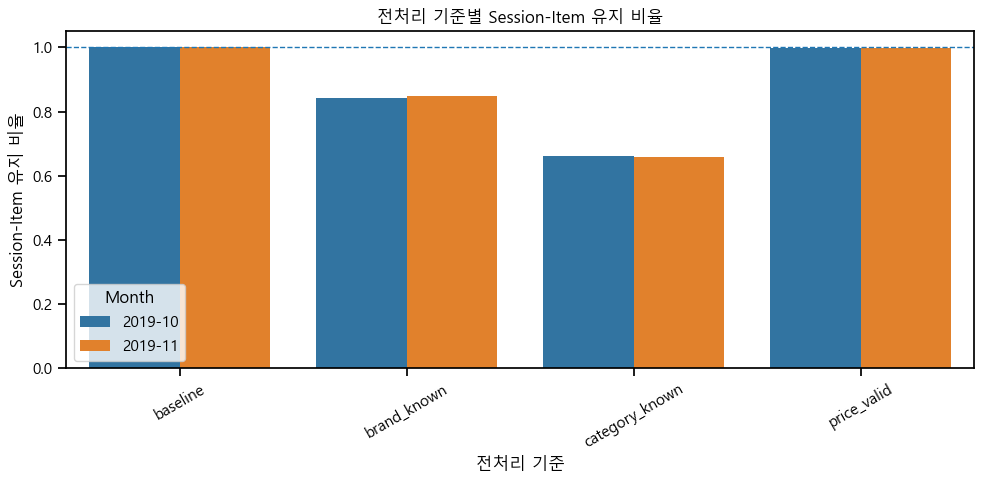

In [27]:
plot_df = sensitivity_summary.copy()
plot_df["retained_ratio"] = 1 + plot_df["session_item_cnt_diff_rate"]

plt.figure(figsize=(10, 5))
sns.barplot(
    data=plot_df,
    x="filter_type",
    y="retained_ratio",
    hue="month",
    order=filter_types
)

plt.axhline(1, linestyle="--", linewidth=1)
plt.title("전처리 기준별 Session-Item 유지 비율")
plt.xlabel("전처리 기준")
plt.ylabel("Session-Item 유지 비율")
plt.xticks(rotation=30)
plt.legend(title="Month")
plt.tight_layout()
plt.show()


- 1에 가까우면 데이터 감소가 거의 없는 기준
- 낮아지면 분석 대상이 많이 줄어든다는 의미

#### 2: 전처리 기준별 Purchase Rate 비교

전처리 기준을 바꿨을 때 구매 전환율이 어떻게 달라지는지 확인


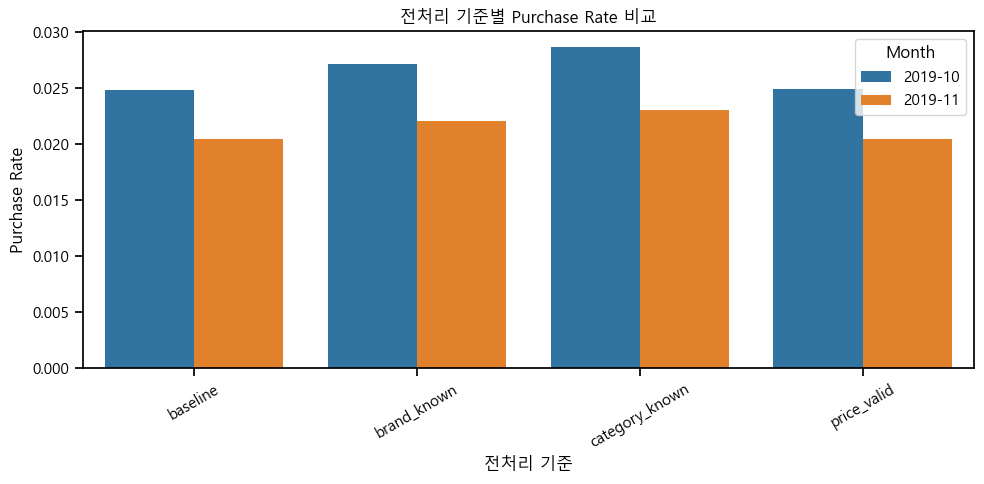

In [28]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=sensitivity_summary,
    x="filter_type",
    y="purchase_rate",
    hue="month",
    order=filter_types
)

plt.title("전처리 기준별 Purchase Rate 비교")
plt.xlabel("전처리 기준")
plt.ylabel("Purchase Rate")
plt.xticks(rotation=30)
plt.legend(title="Month")
plt.tight_layout()
plt.show()


##### 3: Baseline 대비 Purchase Rate 변화량

baseline 대비 purchase rate가 얼마나 증가하거나 감소했는지 확인
- 전처리 기준이 구매 전환율 해석에 영향을 주는지 판단하는 데 사용

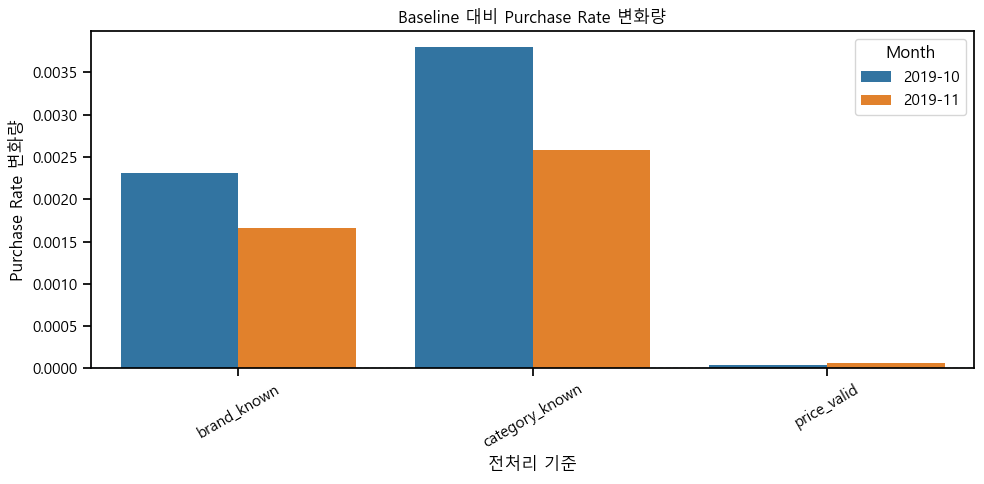

In [29]:
diff_df = sensitivity_summary[sensitivity_summary["filter_type"] != "baseline"].copy()

plt.figure(figsize=(10, 5))
sns.barplot(
    data=diff_df,
    x="filter_type",
    y="purchase_rate_diff",
    hue="month",
    order=[ft for ft in filter_types if ft != "baseline"]
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Baseline 대비 Purchase Rate 변화량")
plt.xlabel("전처리 기준")
plt.ylabel("Purchase Rate 변화량")
plt.xticks(rotation=30)
plt.legend(title="Month")
plt.tight_layout()
plt.show()


#### 4: 전처리 기준별 핵심 지표 변화 Heatmap

전처리 기준별로 어떤 지표가 가장 민감하게 변하는지 확인

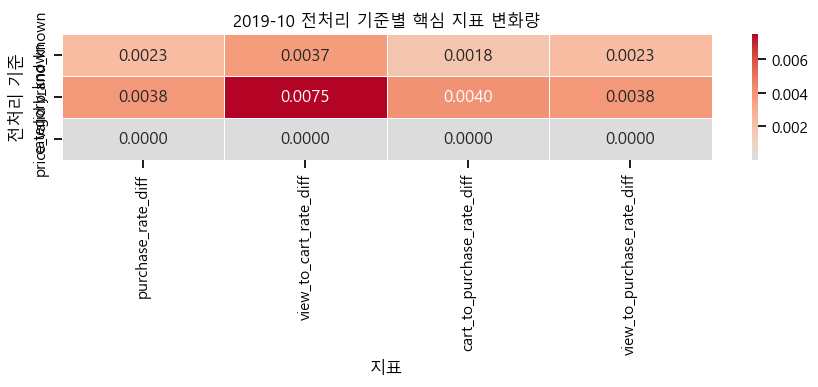

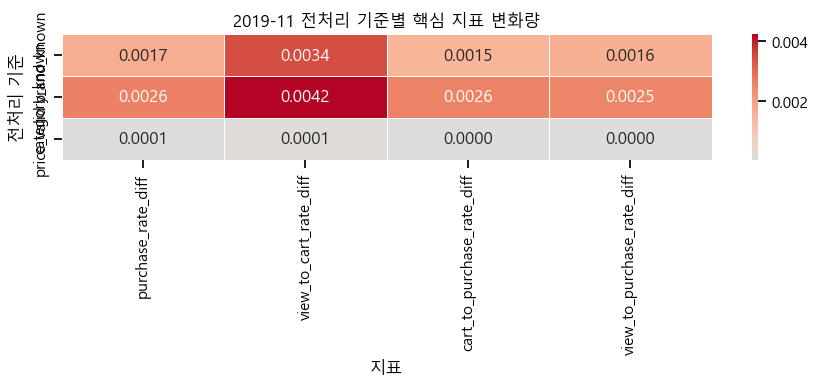

In [30]:
heatmap_df = sensitivity_summary[
    sensitivity_summary["filter_type"] != "baseline"
].copy()

metric_cols = [
    "purchase_rate_diff",
    "view_to_cart_rate_diff",
    "cart_to_purchase_rate_diff",
    "view_to_purchase_rate_diff"
]

for month in heatmap_df["month"].unique():
    temp = heatmap_df[heatmap_df["month"] == month].copy()
    temp = temp.set_index("filter_type")[metric_cols]

    plt.figure(figsize=(9, 4))
    sns.heatmap(
        temp,
        annot=True,
        fmt=".4f",
        cmap="coolwarm",
        center=0,
        linewidths=0.5
    )

    plt.title(f"{month} 전처리 기준별 핵심 지표 변화량")
    plt.xlabel("지표")
    plt.ylabel("전처리 기준")
    plt.tight_layout()
    plt.show()


- 값이 0에 가까우면 baseline과 거의 차이가 없음
- 양수는 baseline보다 지표 상승
- 음수는 baseline보다 지표 하락

#### 5: 전처리 기준별 구매 소요 시간 중앙값 비교

전처리 기준에 따라 구매까지 걸린 시간의 중앙값이 달라지는지 확인
- 구매 행동 해석에도 전처리 기준이 영향을 주는지 확인하기 위한 보조 지표

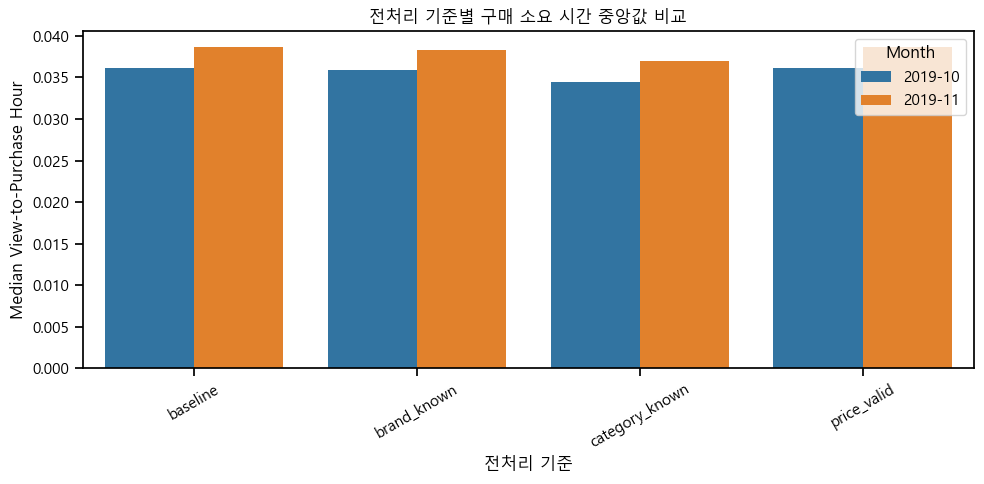

In [31]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=sensitivity_summary,
    x="filter_type",
    y="median_view_to_purchase_hour",
    hue="month",
    order=filter_types
)

plt.title("전처리 기준별 구매 소요 시간 중앙값 비교")
plt.xlabel("전처리 기준")
plt.ylabel("Median View-to-Purchase Hour")
plt.xticks(rotation=30)
plt.legend(title="Month")
plt.tight_layout()
plt.show()


#### 6: 데이터 감소율 대비 Purchase Rate 변화

각 전처리 기준이 데이터 수를 얼마나 줄였고, 그 결과 purchase rate가 얼마나 변했는지 함께 확인

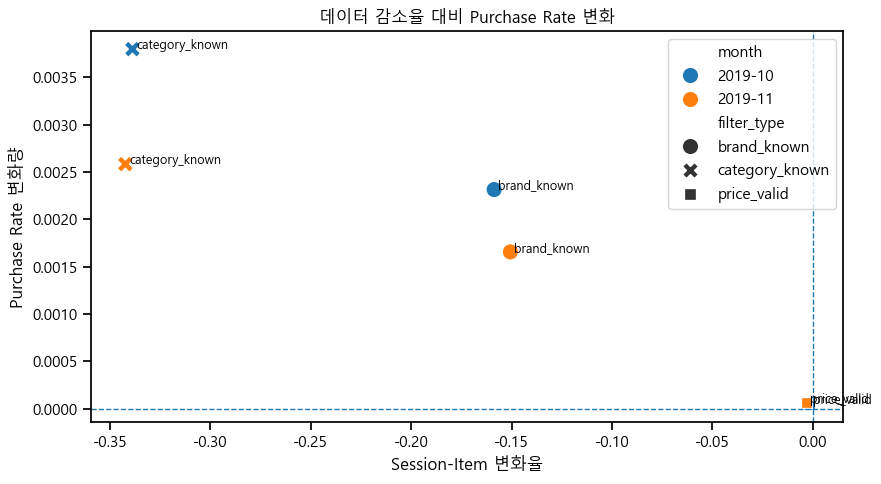

In [32]:
scatter_df = sensitivity_summary[
    sensitivity_summary["filter_type"] != "baseline"
].copy()

plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=scatter_df,
    x="session_item_cnt_diff_rate",
    y="purchase_rate_diff",
    hue="month",
    style="filter_type",
    s=140
)

for _, row in scatter_df.iterrows():
    plt.text(
        row["session_item_cnt_diff_rate"] + 0.002,
        row["purchase_rate_diff"],
        row["filter_type"],
        fontsize=9
    )

plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)
plt.title("데이터 감소율 대비 Purchase Rate 변화")
plt.xlabel("Session-Item 변화율")
plt.ylabel("Purchase Rate 변화량")
plt.tight_layout()
plt.show()


- 왼쪽으로 갈수록 해당 기준 적용 시 분석 대상 감소
- 위쪽으로 갈수록 baseline 대비 purchase rate가 상승
- 데이터 감소가 크면서 purchase rate가 상승한다면, 제외된 데이터가 상대적으로 구매 전환율이 낮은 그룹

#### 7: 결측 여부별 event_type 구성비

`brand_missing` 또는 `category_missing` 여부에 따라 view/cart/purchase 구성비가 어떻게 달라지는지 확인

In [33]:
def make_missing_event_mix(file_path, month, missing_col="brand", chunksize=500_000):
    """
    결측 여부별 event_type 구성비 계산 함수

    missing_col:
    - 'brand'
    - 'category_code'
    """

    result = []
    usecols = ["event_type", missing_col]

    for chunk in pd.read_csv(file_path, chunksize=chunksize, usecols=usecols):
        temp = chunk.copy()
        temp["missing_yn"] = temp[missing_col].isna().astype(int)

        grouped = (
            temp.groupby(["missing_yn", "event_type"])
            .size()
            .reset_index(name="cnt")
        )

        grouped["month"] = month
        grouped["missing_col"] = missing_col
        result.append(grouped)

    event_mix = pd.concat(result, ignore_index=True)

    event_mix = (
        event_mix.groupby(["month", "missing_col", "missing_yn", "event_type"], as_index=False)["cnt"]
        .sum()
    )

    event_mix["ratio"] = (
        event_mix["cnt"] / event_mix.groupby(["month", "missing_col", "missing_yn"])["cnt"].transform("sum")
    )

    return event_mix


In [34]:
brand_event_mix_list = []

for month, file_path in files.items():
    brand_event_mix_list.append(
        make_missing_event_mix(
            file_path=file_path,
            month=month,
            missing_col="brand",
            chunksize=chunksize
        )
    )

brand_event_mix = pd.concat(brand_event_mix_list, ignore_index=True)
brand_event_mix

,month,missing_col,missing_yn,event_type,cnt,ratio
0,2019-10,brand,0,cart,907710,0.02
1,2019-10,brand,0,purchase,684544,0.02
2,2019-10,brand,0,view,34739430,0.96
3,2019-10,brand,1,cart,18806,0.00
4,2019-10,brand,1,purchase,58305,0.01
5,2019-10,brand,1,view,6039969,0.99
6,2019-11,brand,0,cart,2770399,0.05
7,2019-11,brand,0,purchase,843577,0.01
8,2019-11,brand,0,view,54663925,0.94
9,2019-11,brand,1,cart,258531,0.03


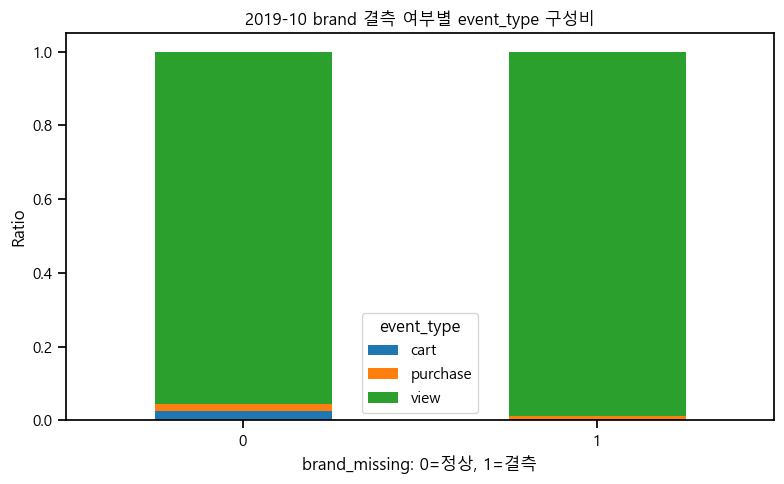

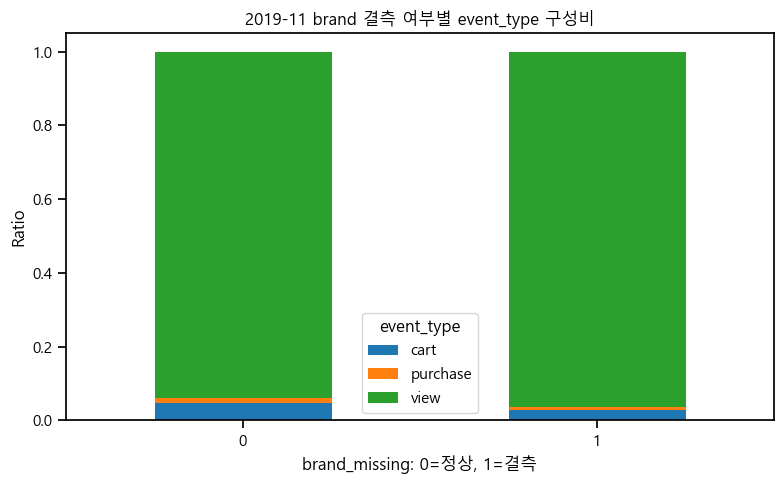

In [35]:
for month in brand_event_mix["month"].unique():
    temp = brand_event_mix[brand_event_mix["month"] == month].copy()
    pivot_df = temp.pivot(index="missing_yn", columns="event_type", values="ratio").fillna(0)

    pivot_df.plot(kind="bar", stacked=True, figsize=(8, 5))
    plt.title(f"{month} brand 결측 여부별 event_type 구성비")
    plt.xlabel("brand_missing: 0=정상, 1=결측")
    plt.ylabel("Ratio")
    plt.xticks(rotation=0)
    plt.legend(title="event_type")
    plt.tight_layout()
    plt.show()


### EDA 결과 해석

#### 1. 분석 목적

전처리 기준이 실제 핵심 퍼널 지표에 미치는 영향을 확인<br>
특히 `brand` 결측, `category_code` 결측, `price <= 0` 데이터를 포함하거나 제외했을 때 session-item 기준 전환율이 얼마나 달라지는지 비교

`purchase_rate`, `view_to_cart_rate`, `cart_to_purchase_rate` 등 주요 퍼널 지표가 얼마나 민감하게 변하는지 확인

---

#### 2. 주요 결과

##### 1) brand 결측 제외 기준

brand 결측 데이터를 제외하면 session-item 수는 10월 약 15.87%, 11월 약 15.06% 감소
- purchase_rate는 두 달 모두 상승하였다.

- brand 결측 데이터가 단순 누락값이 아니라, 상대적으로 구매 전환율이 낮은 탐색 중심 데이터일 가능성 있음<br>
=>  제거하기보다는 `unknown_brand` 그룹으로 별도 유지하는 것이 타당<br>
즉, brand 결측을 제거하면 전환율은 다소 높아지지만, 이는 실제 구매력이 높아졌다기보다 구매 가능성이 낮은 결측 그룹이 분석 대상에서 빠졌기 때문으로 해석

---

##### 2) category_code 결측 제외 기준

category_code 결측 데이터를 제외하면 session-item 수가 10월 약 33.88%, 11월 약 34.24% 감소
- category_code 결측이 전체 데이터에서 상당히 큰 비중을 차지한다는 것을 의미

view_to_cart_rate와 purchase_rate가 모두 상승\
- category_code가 명확한 상품군이 결측 상품군보다 상대적으로 구매 전환 가능성이 높음

=> 전체 퍼널 분석에서는 `unknown_category`로 유지하는 것이 적절
- 특정 카테고리의 행동을 정밀하게 볼 때는 category_code가 명확한 데이터 중심으로 분석하는 것이 더 안정적

---

##### 3) price invalid 제외 기준

price_invalid 데이터를 제외했을 때 session-item 수는 10월 약 0.18%, 11월 약 0.32%만 감소
- purchase_rate, view_to_cart_rate, cart_to_purchase_rate 변화 매우 작음

- price <= 0 데이터는 전체 퍼널 전환율 해석에는 큰 영향을 주지 않음
- 가격 또는 매출 관련 분석에서는 제외하고, 퍼널 분석에서는 `price_invalid` 플래그로 관리하는 것이 적절

---

##### 4) 반복구매 이상치 후보 기준

`baseline`, `brand_known`, `category_known`, `price_valid` 기준을 우선 비교

- 별도 전처리 과정에서 생성한 플래그 컬럼이므로 전처리 완료 파일을 기준으로 추가 비교

---

#### 3. 최종 판단

전처리 기준별로 핵심 퍼널 지표를 비교한 결과, `brand` 결측과 `category_code` 결측은 purchase_rate 및 전환율 해석에 영향

category_code 결측 제외 기준은 session-item 수를 약 34% 감소시키면서 view_to_cart_rate와 purchase_rate를 모두 상승
- category_code 결측 데이터가 단순한 누락이 아니라, 상대적으로 전환 가능성이 낮은 탐색 중심 데이터 가능성

=> 따라서 전체 퍼널 분석에서는 큰 영향을 주지 않지만, 가격·매출 분석에서는 별도 관리가 필요하다.


| 항목 | 최종 처리 기준 |
|---|---|
| 중복 행 | 제거 후 분석 |
| brand 결측 | `unknown_brand`로 유지, 브랜드 분석에서는 별도 그룹 처리 |
| category_code 결측 | `unknown_category`로 유지, 스마트폰 심화 분석에서는 명확한 category 중심 분석 |
| price <= 0 | 가격/매출 분석에서는 제외, 퍼널 분석에서는 플래그 유지 |
| 반복구매 이상치 후보 | 삭제보다 플래그 처리, 전처리 완료 파일 기준으로 포함/제외 민감도 추가 비교 |